In [3]:
from langgraph.graph import  StateGraph, START, END
from typing import TypedDict

In [5]:
class State(TypedDict):
    number_a : int
    number_b : int
    
    multiplication : int
    addition : int
    subtraction : int
    division : int

In [8]:
def multiply(state: State) -> State:
    result = state['number_a'] * state['number_b']
    return { 'multiplication': result }

def add(state: State) -> State:
    result = state['number_a'] + state['number_b']
    return { 'addition': result }

def subtract(state: State) -> State:
    result = state['number_a'] - state['number_b']
    return { 'subtraction': result }

def divide(state: State) -> State:
    result = state['number_a'] / state['number_b']
    return { 'division': result }

def final_state(state: State) -> State:
    return state

In [10]:
graph = StateGraph(State)

graph.add_node("multiply", multiply)
graph.add_node("add", add)
graph.add_node("subtract", subtract)
graph.add_node("divide", divide)

graph.add_node("final_state", final_state)

graph.add_edge(START, "multiply")
graph.add_edge(START, "add")
graph.add_edge(START, "subtract")
graph.add_edge(START, "divide")

graph.add_edge('multiply', 'final_state')
graph.add_edge('add', 'final_state')
graph.add_edge('subtract', 'final_state')
graph.add_edge('divide', 'final_state')

graph.add_edge('final_state', END)

workflow = graph.compile()

In [12]:
input_state = {
    'number_a': 10,
    'number_b': 5
}

result = workflow.invoke(input_state)
print(result)

{'number_a': 10, 'number_b': 5, 'multiplication': 50, 'addition': 15, 'subtraction': 5, 'division': 2.0}


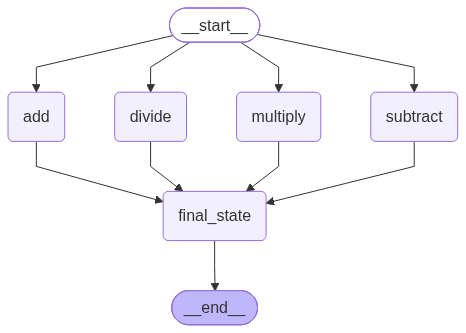

In [13]:
from IPython.display import Image,display
display(Image(workflow.get_graph().draw_mermaid_png()))